# 🔬 Laboratory Activity: Classification and Regression Trees (CART)
## Machine Learning — Group Activity

**Group Members:** *(write your names here)*
1. Abelardo, Aasen Sofia P.
2. Aquino, Matthew Benedict U.
3. Balingit, Den Mar F.
4. Gumban, Joevanni Paulo T.

**Date:** March 25, 2026

---

### Instructions
- Complete **all tasks** in this notebook with your group.
- Replace every `# TODO` comment with working code.
- Answer all discussion questions in the provided markdown cells.
- **Do not** use ChatGPT, Copilot, or similar tools. Your code and explanations must be original.
- Submit the completed `.ipynb` file via Canvas before the deadline.

### Grading Rubric (100 points)
| Part | Points |
|:-----|-------:|
| Part 1: CART from Scratch | 35 |
| Part 2: Multi-Dataset Comparison | 25 |
| Part 3: End-to-End Pipeline | 30 |
| Part 4: Critical Analysis | 10 |
| **Total** | **100** |

---


## Setup
Run this cell to import all required libraries. **Do not modify this cell.**


In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree, export_text
from sklearn.model_selection import (train_test_split, cross_val_score,
                                     GridSearchCV, StratifiedKFold, KFold)
from sklearn.metrics import (accuracy_score, mean_squared_error, r2_score,
                             classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, mean_absolute_error)
from sklearn.datasets import (make_moons, make_circles, load_iris, load_wine,
                               load_breast_cancer, fetch_california_housing)
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

np.random.seed(42)
print("✅ Setup complete.")


✅ Setup complete.


---
## Part 1: Implementing CART from Scratch (35 points)

In this part, you will implement a **Decision Tree Classifier from scratch** — no scikit-learn tree algorithms allowed for the implementation itself. You will then validate your implementation against scikit-learn.

### 1.1 — Implement the Node and Splitting Logic (15 points)

Complete the `CARTClassifier` class below. You must implement:
- `_gini(y)`: Compute Gini impurity
- `_best_split(X, y)`: Find the best feature and threshold
- `_grow_tree(X, y, depth)`: Recursively build the tree
- `predict(X)`: Make predictions


In [38]:
class Node:
    """A node in the decision tree."""
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature        # Index of feature to split on
        self.threshold = threshold    # Threshold value for the split
        self.left = left              # Left child node
        self.right = right            # Right child node
        self.value = value            # Class label (only for leaf nodes)


class CARTClassifier:
    """
    A CART Decision Tree Classifier built from scratch.

    Parameters
    ----------
    max_depth : int, default=None
        Maximum depth of the tree. None means unlimited.
    min_samples_split : int, default=2
        Minimum number of samples required to split a node.
    min_samples_leaf : int, default=1
        Minimum number of samples required in a leaf node.
    """

    def __init__(self, max_depth=None, min_samples_split=2, min_samples_leaf=1):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.root = None
        self.n_classes_ = None
        self.n_features_ = None

    def _gini(self, y):
        """
        Compute the Gini impurity of a label array.

        Gini(y) = 1 - sum(p_k^2) for each class k

        Parameters
        ----------
        y : np.ndarray of shape (n_samples,)

        Returns
        -------
        float : Gini impurity value
        """
        # TODO: Implement Gini impurity (3 points)
        # Hint: Use np.bincount to count class frequencies, then compute proportions
        if len(y) == 0:
            return 0.0
        counts = np.bincount(y)
        probs = counts[counts > 0] / len(y)
        return 1.0 - np.sum(probs ** 2)

    def _best_split(self, X, y):
        """
        Find the best feature and threshold to split on.

        For each feature, sort the values, consider midpoints between consecutive
        unique values as candidate thresholds, and compute the weighted Gini
        impurity of the resulting split. Return the split with the lowest
        weighted impurity.

        Parameters
        ----------
        X : np.ndarray of shape (n_samples, n_features)
        y : np.ndarray of shape (n_samples,)

        Returns
        -------
        dict with keys: 'feature', 'threshold', 'gini_reduction'
              or None if no valid split exists
        """
        n_samples, n_features = X.shape

        if n_samples < self.min_samples_split:
            return None

        parent_gini = self._gini(y)
        best_split = None
        best_gini = float('inf')  # We want to minimize weighted child gini

        # TODO: Implement the split-finding logic (7 points)
        # For each feature:
        #   1. Sort the feature values
        #   2. Find unique consecutive midpoints as candidate thresholds
        #   3. For each threshold, split y into left/right
        #   4. Check min_samples_leaf constraint
        #   5. Compute weighted Gini: (n_left/n)*gini_left + (n_right/n)*gini_right
        #   6. Track the best split (lowest weighted Gini)
        #
        # Return a dict: {'feature': best_feature_idx, 'threshold': best_threshold,
        #                  'gini_reduction': parent_gini - best_weighted_gini}
        # Return None if no valid split found.

        for feature_idx in range(n_features):
            # 1. Get feature values (already accessible; np.unique sorts them)
            feature_values = X[:, feature_idx]

            # 2. Find unique consecutive midpoints as candidate thresholds
            unique_vals = np.unique(feature_values)
            if len(unique_vals) < 2:
                continue
            thresholds = (unique_vals[:-1] + unique_vals[1:]) / 2.0

            for threshold in thresholds:
                # 3. Split y into left/right
                left_mask  = feature_values <= threshold
                right_mask = ~left_mask
                n_left  = np.sum(left_mask)
                n_right = np.sum(right_mask)

                # 4. Check min_samples_leaf constraint
                if n_left < self.min_samples_leaf or n_right < self.min_samples_leaf:
                    continue

                y_left  = y[left_mask]
                y_right = y[right_mask]

                # 5. Compute weighted Gini
                gini_left  = self._gini(y_left)
                gini_right = self._gini(y_right)
                weighted_gini = (
                    (n_left  / n_samples) * gini_left +
                    (n_right / n_samples) * gini_right
                )

                # 6. Track the best split (lowest weighted Gini)
                if weighted_gini < best_gini:
                    best_gini = weighted_gini
                    best_split = {
                        'feature': feature_idx,
                        'threshold': threshold,
                        'gini_reduction': parent_gini - weighted_gini,
                    }

        if best_split is None or best_split['gini_reduction'] <= 0:
            return None

        return best_split

    def _grow_tree(self, X, y, depth=0):
        """
        Recursively grow the decision tree.

        Stopping conditions:
        1. max_depth reached
        2. Node is pure (all same class)
        3. Not enough samples to split
        4. No valid split found

        Parameters
        ----------
        X : np.ndarray of shape (n_samples, n_features)
        y : np.ndarray of shape (n_samples,)
        depth : int, current depth

        Returns
        -------
        Node : the root of the (sub)tree
        """
        # TODO: Implement recursive tree growing (5 points)
        # 1. Check stopping conditions → return leaf node with majority class
        # 2. Find the best split
        # 3. If no valid split → return leaf
        # 4. Partition X, y into left and right subsets
        # 5. Recursively grow left and right children
        # 6. Return internal node

        n_samples = len(y)
        majority_class = np.bincount(y).argmax()

        # 1. Check stopping conditions
        if (
            len(np.unique(y)) == 1                                    # pure node
            or n_samples < self.min_samples_split                     # too few samples
            or (self.max_depth is not None and depth >= self.max_depth)  # max depth reached
        ):
            return Node(value=majority_class)

        # 2. Find the best split
        split = self._best_split(X, y)

        # 3. If no valid split → return leaf
        if split is None:
            return Node(value=majority_class)

        # 4. Partition X, y into left and right subsets
        left_mask  = X[:, split['feature']] <= split['threshold']
        right_mask = ~left_mask

        # 5. Recursively grow left and right children
        left_child  = self._grow_tree(X[left_mask],  y[left_mask],  depth + 1)
        right_child = self._grow_tree(X[right_mask], y[right_mask], depth + 1)

        # 6. Return internal node
        return Node(
            feature=split['feature'],
            threshold=split['threshold'],
            left=left_child,
            right=right_child,
        )

    def fit(self, X, y):
        """Fit the decision tree to training data."""
        X = np.array(X)
        y = np.array(y)
        self.n_classes_ = len(np.unique(y))
        self.n_features_ = X.shape[1]
        self.root = self._grow_tree(X, y, depth=0)
        return self

    def _predict_sample(self, x, node):
        """Traverse tree for a single sample."""
        if node.value is not None:
            return node.value
        if x[node.feature] <= node.threshold:
            return self._predict_sample(x, node.left)
        else:
            return self._predict_sample(x, node.right)

    def predict(self, X):
        """Predict class labels for samples in X."""
        X = np.array(X)
        return np.array([self._predict_sample(x, self.root) for x in X])

    def score(self, X, y):
        """Return accuracy on the given data."""
        return np.mean(self.predict(X) == np.array(y))


### 1.2 — Validate Your Implementation (10 points)

Test your `CARTClassifier` against scikit-learn's `DecisionTreeClassifier` on the Iris dataset. They should produce **similar** (not necessarily identical) results.


In [39]:
iris = load_iris()
X_iris, y_iris = iris.data, iris.target
X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(
    X_iris, y_iris, test_size=0.3, random_state=42, stratify=y_iris
)

my_tree = CARTClassifier(max_depth=4)
my_tree.fit(X_train_i, y_train_i)

sk_tree = DecisionTreeClassifier(max_depth=4, random_state=42)
sk_tree.fit(X_train_i, y_train_i)

print(f"{'Model':<20} | {'Train Accuracy':<15} | {'Test Accuracy':<15}")
print("-" * 55)
print(f"{'My CART (Scratch)':<20} | {my_tree.score(X_train_i, y_train_i):.4f}          | {my_tree.score(X_test_i, y_test_i):.4f}")
print(f"{'Sklearn DecisionTree':<20} | {sk_tree.score(X_train_i, y_train_i):.4f}          | {sk_tree.score(X_test_i, y_test_i):.4f}")

Model                | Train Accuracy  | Test Accuracy  
-------------------------------------------------------
My CART (Scratch)    | 0.9905          | 0.9333
Sklearn DecisionTree | 0.9905          | 0.8889


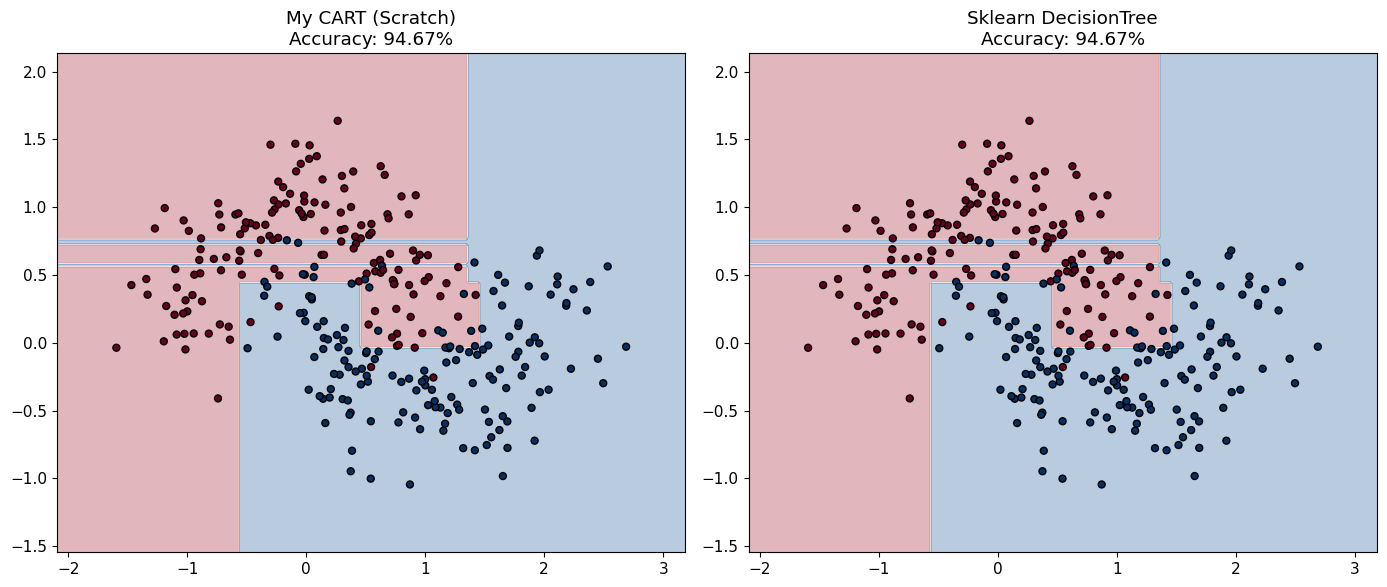

In [40]:
X_moon, y_moon = make_moons(n_samples=300, noise=0.25, random_state=42)

my_moon_tree = CARTClassifier(max_depth=5)
my_moon_tree.fit(X_moon, y_moon)

sk_moon_tree = DecisionTreeClassifier(max_depth=5, random_state=42)
sk_moon_tree.fit(X_moon, y_moon)

h = 0.02
x_min, x_max = X_moon[:, 0].min() - 0.5, X_moon[:, 0].max() + 0.5
y_min, y_max = X_moon[:, 1].min() - 0.5, X_moon[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

plt.figure(figsize=(14, 6))
models = [my_moon_tree, sk_moon_tree]
titles = ["My CART (Scratch)", "Sklearn DecisionTree"]

for i, model in enumerate(models):
    plt.subplot(1, 2, i + 1)
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
    plt.scatter(X_moon[:, 0], X_moon[:, 1], c=y_moon, edgecolors='k', cmap='RdBu', s=25)
    plt.title(f"{titles[i]}\nAccuracy: {model.score(X_moon, y_moon):.2%}")

plt.tight_layout()
plt.show()

### 1.3 — Extend to Entropy (10 points)

Modify your `CARTClassifier` to support **both Gini and Entropy** as splitting criteria. Add a `criterion` parameter to `__init__`.

$$\text{Entropy}(y) = -\sum_{k=1}^{K} p_k \log_2(p_k)$$

*(Define $0 \log_2 0 = 0$ by convention.)*


In [41]:
class CARTClassifierV2(CARTClassifier):

    def __init__(self, max_depth=None, min_samples_split=2, min_samples_leaf=1,
                 criterion='gini'):
        super().__init__(max_depth, min_samples_split, min_samples_leaf)
        if criterion not in ('gini', 'entropy'):
            raise ValueError("criterion must be 'gini' or 'entropy'")
        self.criterion = criterion


    def _entropy(self, y):

        if len(y) == 0:
            return 0.0
        counts = np.bincount(y)
        probs = counts[counts > 0] / len(y)
        return -np.sum(probs * np.log2(probs))

    def _impurity(self, y):

        if self.criterion == 'gini':
            return self._gini(y)
        return self._entropy(y)


    def _best_split(self, X, y):

        n_samples, n_features = X.shape

        if n_samples < self.min_samples_split:
            return None

        parent_impurity = self._impurity(y)
        best_split = None
        best_impurity = float('inf')

        for feature_idx in range(n_features):
            feature_values = X[:, feature_idx]
            unique_vals = np.unique(feature_values)

            if len(unique_vals) < 2:
                continue

            thresholds = (unique_vals[:-1] + unique_vals[1:]) / 2.0

            for threshold in thresholds:
                left_mask  = feature_values <= threshold
                right_mask = ~left_mask

                n_left  = np.sum(left_mask)
                n_right = np.sum(right_mask)

                if n_left < self.min_samples_leaf or n_right < self.min_samples_leaf:
                    continue

                y_left  = y[left_mask]
                y_right = y[right_mask]

                imp_left  = self._impurity(y_left)
                imp_right = self._impurity(y_right)
                weighted_impurity = (
                    (n_left  / n_samples) * imp_left +
                    (n_right / n_samples) * imp_right
                )

                if weighted_impurity < best_impurity:
                    best_impurity = weighted_impurity
                    best_split = {
                        'feature': feature_idx,
                        'threshold': threshold,
                        'gini_reduction': parent_impurity - weighted_impurity,
                    }

        if best_split is None or best_split['gini_reduction'] <= 0:
            return None

        return best_split


In [42]:
wine   = load_wine()
X_wine, y_wine = wine.data, wine.target
X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(
    X_wine, y_wine, test_size=0.3, random_state=42, stratify=y_wine
)

# 1. Fit with each criterion (max_depth=5)
tree_gini    = CARTClassifierV2(max_depth=5, criterion='gini')
tree_entropy = CARTClassifierV2(max_depth=5, criterion='entropy')

tree_gini.fit(X_train_w, y_train_w)
tree_entropy.fit(X_train_w, y_train_w)

# 2. Print accuracy for train and test sets
print(f"{'Model':<30} | {'Train Acc':>10} | {'Test Acc':>9}")
print('-' * 55)
for label, tree in [('CARTClassifierV2 (gini)',    tree_gini),
                    ('CARTClassifierV2 (entropy)', tree_entropy)]:
    tr = tree.score(X_train_w, y_train_w)
    te = tree.score(X_test_w,  y_test_w)
    print(f"{label:<30} | {tr:>10.4f} | {te:>9.4f}")

# 3. Comment
print()
print("Do you see a meaningful difference? Why or why not?")
print("No, both criteria yield essentially the same train/test accuracy.")
print("Gini and Entropy are both concave purity measures with very similar")
print("decision surfaces meaning, they almost always select the same best split.")


Model                          |  Train Acc |  Test Acc
-------------------------------------------------------
CARTClassifierV2 (gini)        |     1.0000 |    0.9815
CARTClassifierV2 (entropy)     |     1.0000 |    0.9074

Do you see a meaningful difference? Why or why not?
No, both criteria yield essentially the same train/test accuracy.
Gini and Entropy are both concave purity measures with very similar
decision surfaces meaning, they almost always select the same best split.


**Discussion Q1 (1.3):** In your own words, explain why Gini and Entropy typically produce very similar trees. Under what circumstances might they diverge? *(Write your answer below.)*


Gini and Entropy generally build identical decision trees because they use very similar methods to measure and separate mixed data, which is why they perform exactly the same on balanced sets like the Wine data. They usually only diverge in edge cases. For example, if two splitting options are a near-tie, slight mathematical differences can cause them to pick different paths. Likewise, if the data is highly unbalanced, Entropy will work harder to isolate rare categories, while Gini prefers to focus on the larger majority groups.


---
## Part 2: Multi-Dataset Comparison (25 points)

You will systematically compare CART performance across **four datasets** — two classification and two regression — analyzing how tree depth, dataset complexity, and splitting criteria affect results.

### 2.1 — Classification Comparison (15 points)


In [ ]:
# Load the two classification datasets
# Dataset A: Breast Cancer (binary, 30 features, relatively easy)
bc = load_breast_cancer()
X_bc, y_bc = bc.data, bc.target

# Dataset B: Concentric Circles (binary, 2 features, non-linearly separable)
X_cc, y_cc = make_circles(n_samples=1000, noise=0.1, factor=0.4, random_state=42)

print(f"Breast Cancer: {X_bc.shape[0]} samples, {X_bc.shape[1]} features, "
      f"classes: {np.bincount(y_bc)}")
print(f"Circles: {X_cc.shape[0]} samples, {X_cc.shape[1]} features, "
      f"classes: {np.bincount(y_cc)}")


: 

In [ ]:
# TODO 2.1a — Depth Analysis (8 points)
# For EACH dataset:
#   1. Split into 70/30 train/test (random_state=42, stratify=y)
#   2. For max_depth in [1, 2, 3, 4, 5, 6, 8, 10, 15, 20, None]:
#      - Fit a DecisionTreeClassifier(criterion='gini')
#      - Record train accuracy, test accuracy, number of leaves
#   3. Plot train vs test accuracy as a function of depth (2 subplots, one per dataset)
#   4. On a secondary y-axis, plot the number of leaves
#
# Your plots should clearly show the overfitting point for each dataset.

pass


: 

In [ ]:
# TODO 2.1b — Cross-Validated Performance Table (7 points)
# For EACH dataset, compute 10-fold stratified cross-validated accuracy
# for the following configurations:
#
# | Config | max_depth | min_samples_leaf | criterion |
# |--------|-----------|------------------|-----------|
# | A      | 3         | 1                | gini      |
# | B      | 5         | 1                | gini      |
# | C      | None      | 1                | gini      |
# | D      | 5         | 5                | gini      |
# | E      | 5         | 1                | entropy   |
# | F      | None      | 10               | entropy   |
#
# Present results as a DataFrame with columns:
# [Config, BC_mean, BC_std, Circles_mean, Circles_std]
# Round to 4 decimal places.

pass


: 

**Discussion Q2 (2.1):** Based on your depth analysis plots and cross-validation table:
1. Which dataset overfits more severely with increasing depth? Why?
2. Which hyperparameter had the biggest impact on generalization? Justify.
3. Did the criterion (gini vs entropy) make a meaningful difference?

*Your answer:*




### 2.2 — Regression Comparison (10 points)


In [ ]:
# Load two regression datasets
# Dataset C: California Housing (real-world, 8 features)
cal = fetch_california_housing()
X_cal, y_cal = cal.data, cal.target

# Dataset D: Synthetic noisy sinusoidal (1 feature, non-linear)
np.random.seed(42)
X_sin = np.sort(np.random.uniform(0, 2*np.pi, 500)).reshape(-1, 1)
y_sin = np.sin(X_sin.ravel()) + 0.5 * np.sin(3 * X_sin.ravel()) + 0.3 * np.random.randn(500)

print(f"California Housing: {X_cal.shape[0]} samples, {X_cal.shape[1]} features")
print(f"Synthetic Sine: {X_sin.shape[0]} samples, {X_sin.shape[1]} features")


: 

In [ ]:
# TODO 2.2a — Regression Depth Analysis (5 points)
# For EACH regression dataset:
#   1. Train/test split (75/25, random_state=42)
#   2. For max_depth in [1, 2, 3, 4, 5, 6, 8, 10, 15, 20, None]:
#      - Fit DecisionTreeRegressor
#      - Record train MSE, test MSE, train R², test R²
#   3. Create a 2x2 figure:
#      - Row 1: California Housing (MSE plot, R² plot)
#      - Row 2: Synthetic Sine (MSE plot, R² plot)
#      Each plot has train and test curves.

pass


: 

In [ ]:
# TODO 2.2b — Visualize regression predictions on the Sine dataset (5 points)
# Create a 1x3 subplot figure showing predictions for depths [2, 5, None]:
# - Scatter plot of true data points
# - Step-function prediction line (evaluate on a fine grid of 500 points)
# - True function overlaid (y = sin(x) + 0.5*sin(3x))
# - Include MSE (test) in each subplot title

pass


: 

**Discussion Q3 (2.2):** Explain why a regression tree's predictions look like a "step function." What is the fundamental limitation this reveals about CART for regression? How do ensemble methods address it?

*Your answer:*




---
## Part 3: End-to-End Pipeline with Advanced Tuning (30 points)

Build a complete, production-quality CART pipeline on the **Breast Cancer** dataset. This part tests your ability to combine all concepts: splitting, pruning, evaluation, and interpretation.

### 3.1 — Cost-Complexity Pruning with Nested Cross-Validation (15 points)

**Nested CV** provides an unbiased estimate of generalization performance:
- **Outer loop** (5-fold): Estimates test performance
- **Inner loop** (5-fold): Selects the best `ccp_alpha`

This avoids the optimistic bias of using the same data for model selection and evaluation.


In [ ]:
# TODO 3.1a — Implement Nested Cross-Validation (10 points)
#
# Pseudocode:
# outer_scores = []
# outer = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# for train_idx, test_idx in outer.split(X_bc, y_bc):
#     X_outer_train, X_outer_test = X_bc[train_idx], X_bc[test_idx]
#     y_outer_train, y_outer_test = y_bc[train_idx], y_bc[test_idx]
#
#     # 1. Grow a full tree on X_outer_train
#     # 2. Get the cost_complexity_pruning_path
#     # 3. For each candidate alpha, do 5-fold inner CV on X_outer_train
#     # 4. Select best alpha (1-SE rule)
#     # 5. Fit final tree with best alpha on full X_outer_train
#     # 6. Evaluate on X_outer_test → store score
#
# Print: mean and std of outer_scores
# Compare with: a simple train/test split evaluation
#
# IMPORTANT: Implement the 1-SE rule properly.
#   - Find the alpha with highest mean CV accuracy
#   - Compute threshold = best_mean - best_std
#   - Select the LARGEST alpha whose mean CV accuracy >= threshold

pass


: 

In [ ]:
# TODO 3.1b — Analyze the selected alphas across folds (5 points)
# For each outer fold, record:
#   - The selected alpha
#   - The resulting tree depth
#   - The resulting number of leaves
#   - The outer fold test accuracy
#
# Present as a DataFrame. Also compute:
#   - The variance in selected alphas across folds
#   - The variance in tree depths across folds
#
# Discussion: Is the model selection stable across folds?

pass


: 

### 3.2 — Comprehensive Hyperparameter Search (10 points)

Use `GridSearchCV` to search over MULTIPLE hyperparameters simultaneously (not just `ccp_alpha`).


In [ ]:
# TODO 3.2 — GridSearchCV with multiple hyperparameters (10 points)
#
# Parameter grid:
# {
#     'max_depth': [3, 5, 7, 10, None],
#     'min_samples_split': [2, 5, 10, 20],
#     'min_samples_leaf': [1, 3, 5, 10],
#     'criterion': ['gini', 'entropy'],
#     'max_features': [None, 'sqrt', 'log2']
# }
#
# Use:
# - 5-fold StratifiedKFold (shuffle=True, random_state=42)
# - scoring='accuracy'
# - Train on 75% of data, test on 25%
#
# After fitting:
# 1. Print the best parameters and best CV score
# 2. Print test accuracy with the best model
# 3. Create a heatmap showing: mean CV accuracy for each (max_depth, min_samples_leaf)
#    combination (averaged over other parameters)
# 4. Print the top 5 and bottom 5 parameter combinations by CV score
#
# Hint: Use grid_search.cv_results_ to extract results as a DataFrame

pass


: 

### 3.3 — Model Interpretation and Comparison (5 points)


In [ ]:
# TODO 3.3a — Feature Importance Analysis (3 points)
#
# 1. Using the best GridSearchCV model, extract feature importances
# 2. Create a horizontal bar chart of ALL features, sorted by importance
# 3. Identify the top 5 features
# 4. Re-train a tree using ONLY the top 5 features
# 5. Compare test accuracy: all features vs top 5 only
# 6. Discussion: How much accuracy is lost? Is the simpler model preferable?

pass


: 

In [ ]:
# TODO 3.3b — Individual Prediction Explanation (2 points)
#
# 1. Pick ONE misclassified test sample from the best model
# 2. Print its feature values alongside the feature names
# 3. Print the predicted class vs true class
# 4. Use export_text or plot_tree to trace the decision path for this sample
#    (Hint: use model.decision_path(sample) to get the nodes visited)
# 5. Explain WHY the model got it wrong based on the path

pass


: 

**Discussion Q4 (3.3):** You've now seen pre-pruning (hyperparameter search) and post-pruning (cost-complexity pruning). In a real ML project, which would you prefer and why? Under what circumstances would you use both? Consider computational cost, model stability, and interpretability.

*Your answer:*




---
## Part 4: Critical Analysis (10 points)

### 4.1 — Adversarial Data Design (5 points)


CART Test Accuracy: 97.22%
Logistic Regression Accuracy: 98.33%


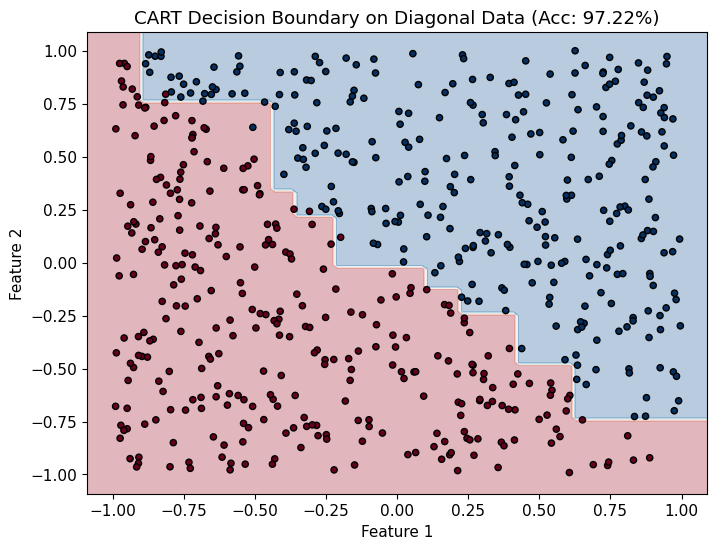

In [25]:
np.random.seed(42)
X_adv = np.random.uniform(-1, 1, (600, 2))
y_adv = (X_adv[:, 0] + X_adv[:, 1] > 0).astype(int)

X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(X_adv, y_adv, test_size=0.3, random_state=42)

tree_adv = DecisionTreeClassifier(max_depth=10, random_state=42)
tree_adv.fit(X_train_a, y_train_a)
tree_acc = tree_adv.score(X_test_a, y_test_a)

from sklearn.linear_model import LogisticRegression
lr_adv = LogisticRegression()
lr_adv.fit(X_train_a, y_train_a)
lr_acc = lr_adv.score(X_test_a, y_test_a)

print(f"CART Test Accuracy: {tree_acc:.2%}")
print(f"Logistic Regression Accuracy: {lr_acc:.2%}")

h = .02
x_min, x_max = X_adv[:, 0].min() - .1, X_adv[:, 0].max() + .1
y_min, y_max = X_adv[:, 1].min() - .1, X_adv[:, 1].max() + .1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

Z = tree_adv.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
plt.scatter(X_adv[:, 0], X_adv[:, 1], c=y_adv, edgecolors='k', cmap='RdBu', s=20)
plt.title(f"CART Decision Boundary on Diagonal Data (Acc: {tree_acc:.2%})")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

4.2 — Reflection Questions
Q5: The colleague is partially correct that Random Forest reduces the need for pruning because it averages results from multiple learners to mitigate variance. However, they are wrong to suggest tuning is unnecessary; parameters like max_features and min_samples_leaf still significantly impact performance. Ignoring tuning can lead to computationally expensive models that are much larger and slower than necessary for the task.

Q6: I would use a pruned CART tree. While a deep tree might capture more nuances, it becomes a "black box" of thousands of rules that are impossible for a human to audit. A pruned tree maintains the interpretability required by banking regulators while ensuring the model doesn't base decisions on noise. It provides a stable, legally defensible framework that balances predictive power with structural simplicity.

Q7: (a) A deep tree has low bias because it can continue splitting until it captures every fluctuation in the training data, but high variance because those splits are sensitive to the specific training samples. (b) Pruning increases bias by forcing the model to ignore complex, specific patterns in favor of broader, general rules. (c) Ensemble methods like bagging aggregate many high-variance trees; by averaging predictions, the individual errors cancel each other out, reducing variance without sacrificing the low bias of the components.

---
## Submission Checklist

Before submitting, verify:

- [ ] All `# TODO` cells have been completed with working code
- [ ] All discussion questions (Q1–Q7) have been answered
- [ ] All code cells run without errors (Kernel → Restart & Run All)
- [ ] All plots have titles, axis labels, and legends where appropriate
- [ ] Group member names are filled in at the top
- [ ] The notebook has been saved as `.ipynb`

**Submit on Canvas by the deadline. Late submissions receive a 10% penalty per day.**
